In [1]:
%cd ..

/Users/kiwifern/Development/airfoil-completion


/Users/kiwifern/Development/airfoil-completion/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from xfoil import XFoil

In [3]:
xf = XFoil()

In [2]:
import numpy as np
import torch

In [6]:
c_mask = torch.Tensor([[33,33,33],[44,44,44]])
c_mask

tensor([[33., 33., 33.],
        [44., 44., 44.]])

In [ ]:
uncond_mask = torch.zeros(c_mask.size(0), dtype=torch.bool)
uncond_mask

tensor([False, False])

In [16]:
p_uncond = 0.5
mask = torch.rand(c_mask.size(0)) < p_uncond
mask

tensor([ True, False])

In [18]:
c_mask * uncond_mask.unsqueeze(1)

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [19]:
c_mask * mask.unsqueeze(1)

tensor([[33., 33., 33.],
        [ 0.,  0.,  0.]])

### 個数での欠損割合

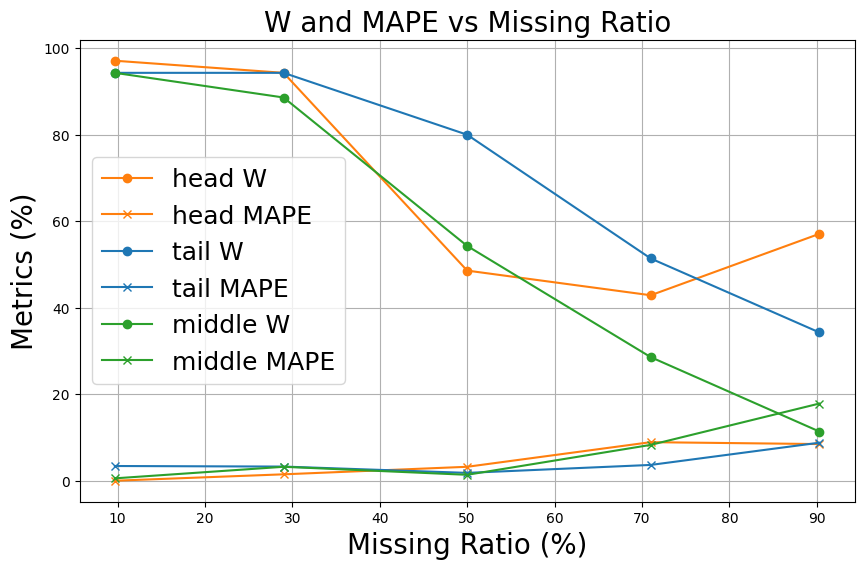

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Data preparation based on the table provided
data = {
    "欠損割合": [9.7, 29.0, 50.0, 71.0, 90.3],
    "head_W": [97.1, 94.3, 48.6, 42.9, 57.1],
    "head_MAPE": [0.04, 1.52, 3.26, 8.95, 8.51],
    "tail_W": [94.3, 94.3, 80.0, 51.4, 34.3],
    "tail_MAPE": [3.44, 3.31, 1.85, 3.69, 8.83],
    "middle_W": [94.3, 88.6, 54.3, 28.6, 11.4],
    "middle_MAPE": [0.59, 3.26, 1.41, 8.32, 17.88],
}

# Creating the DataFrame
df = pd.DataFrame(data)

# Plotting the data with different colors and markers
plt.figure(figsize=(10, 6))

# Head - Same color (Orange), different markers (circle for W, cross for MAPE)
plt.plot(df["欠損割合"], df["head_W"], label="head W", marker="o", color="tab:orange")
plt.plot(df["欠損割合"], df["head_MAPE"], label="head MAPE", marker="x", color="tab:orange")

# Tail - Same color (Blue), different markers (circle for W, cross for MAPE)
plt.plot(df["欠損割合"], df["tail_W"], label="tail W", marker="o", color="tab:blue")
plt.plot(df["欠損割合"], df["tail_MAPE"], label="tail MAPE", marker="x", color="tab:blue")

# Middle - Same color (Green), different markers (circle for W, cross for MAPE)
plt.plot(df["欠損割合"], df["middle_W"], label="middle W", marker="o", color="tab:green")
plt.plot(df["欠損割合"], df["middle_MAPE"], label="middle MAPE", marker="x", color="tab:green")

# Adding titles and labels in English
plt.title("W and MAPE vs Missing Ratio", fontsize=20)
plt.xlabel("Missing Ratio (%)", fontsize=20)
plt.ylabel("Metrics (%)", fontsize=20)
plt.legend(fontsize=18)

# Display the plot
plt.grid(True)
plt.show()

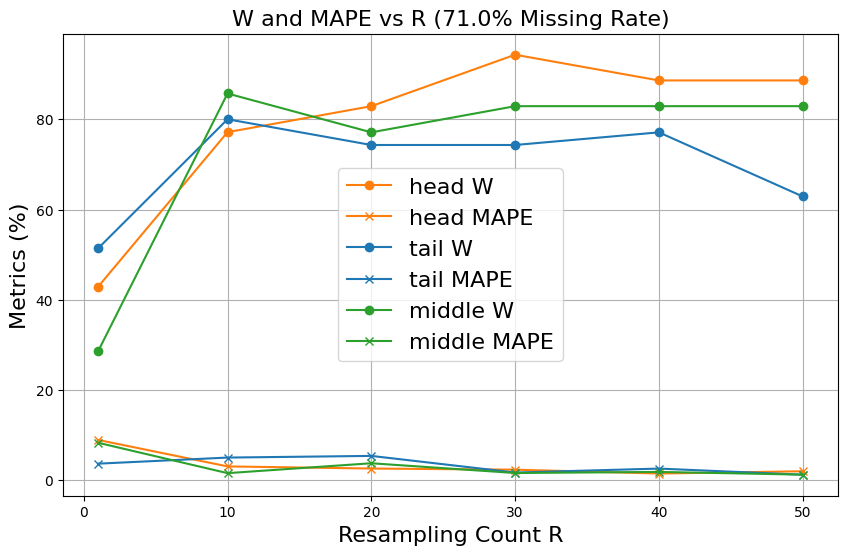

In [3]:
import matplotlib.pyplot as plt

# Resampling回数 R
R_values = [1, 10, 20, 30, 40, 50]

# 欠損割合71.0%における W および MAPE のデータ（手動で表から抽出）
data = {
    "head": {
        "W": [42.9, 77.14, 82.9, 94.3, 88.6, 88.6],
        "MAPE": [8.95, 3.08, 2.61, 2.36, 1.5, 2.01],
    },
    "tail": {
        "W": [51.4, 80.0, 74.3, 74.3, 77.1, 62.9],
        "MAPE": [3.69, 5.04, 5.41, 1.72, 2.6, 1.24],
    },
    "middle": {
        "W": [28.6, 85.71, 77.1, 82.9, 82.9, 82.9],
        "MAPE": [8.32, 1.59, 3.78, 1.62, 1.86, 1.26],
    },
}

# 色の定義（指定通り）
colors = {
    "head": "tab:orange",
    "tail": "tab:blue",
    "middle": "tab:green"
}

# グラフ描画
plt.figure(figsize=(10, 6))

for mode in data:
    plt.plot(R_values, data[mode]["W"], marker="o", label=f"{mode} W", color=colors[mode])
    plt.plot(R_values, data[mode]["MAPE"], marker="x", label=f"{mode} MAPE", color=colors[mode])

# 軸・タイトル・凡例など
plt.xlabel("Resampling Count R", fontsize=16)
plt.ylabel("Metrics (%)", fontsize=16)
plt.title("W and MAPE vs R (71.0% Missing Rate)", fontsize=16)
plt.legend(fontsize=16)

# Display the plot
plt.grid(True)
plt.show()


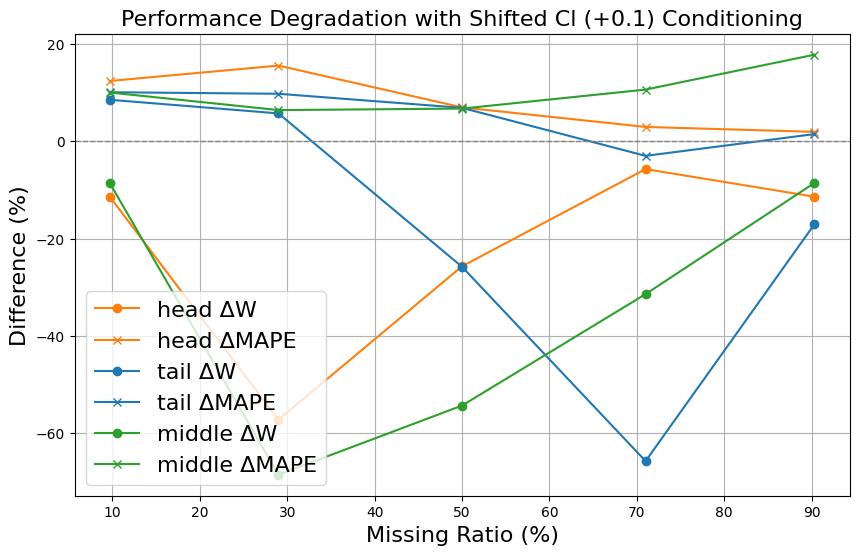

In [8]:
import matplotlib.pyplot as plt

# 欠損割合
missing_ratios = [9.7, 29.0, 50.0, 71.0, 90.3]

# Cl条件での性能データ（WとMAPE）
cl_data = {
    "head": {
        "W": [94.3, 94.3, 94.3, 77.14, 60.0],
        "MAPE": [0.04, 1.31, 1.19, 3.08, 5.62],
    },
    "tail": {
        "W": [88.6, 94.3, 82.9, 80.0, 45.7],
        "MAPE": [0.86, 0.51, 1.09, 5.04, 4.58],
    },
    "middle": {
        "W": [88.6, 97.1, 91.4, 85.71, 34.3],
        "MAPE": [0.59, 1.78, 3.18, 1.59, 2.30],
    },
}

# Cl+0.1条件での性能データ（WとMAPE）
cl_shift_data = {
    "head": {
        "W": [82.9, 37.1, 68.6, 71.4, 48.6],
        "MAPE": [12.40, 16.83, 8.13, 6.00, 7.53],
    },
    "tail": {
        "W": [97.1, 100.0, 57.1, 14.3, 28.6],
        "MAPE": [10.91, 10.24, 7.93, 2.02, 6.03],
    },
    "middle": {
        "W": [80.0, 28.6, 37.1, 54.3, 25.7],
        "MAPE": [10.58, 8.16, 9.87, 12.18, 20.05],
    },
}

# 差分（Cl+0.1 - Cl）を計算
diff_data = {}
for mode in cl_data:
    diff_data[mode] = {
        "delta_W": [s - o for s, o in zip(cl_shift_data[mode]["W"], cl_data[mode]["W"])],
        "delta_MAPE": [s - o for s, o in zip(cl_shift_data[mode]["MAPE"], cl_data[mode]["MAPE"])]
    }

# 色設定
colors = {
    "head": "tab:orange",
    "tail": "tab:blue",
    "middle": "tab:green"
}

# グラフ描画
plt.figure(figsize=(10, 6))
for mode in diff_data:
    plt.plot(missing_ratios, diff_data[mode]["delta_W"], marker='o', label=f"{mode} ΔW", color=colors[mode])
    plt.plot(missing_ratios, diff_data[mode]["delta_MAPE"], marker='x', label=f"{mode} ΔMAPE", color=colors[mode])

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel("Missing Ratio (%)", fontsize=16)
plt.ylabel("Difference (%)", fontsize=16)
plt.title("Performance Degradation with Shifted Cl (+0.1) Conditioning", fontsize=16)
plt.legend(fontsize=16)
plt.grid(True)
# plt.tight_layout()
plt.show()

### x軸での欠損割合

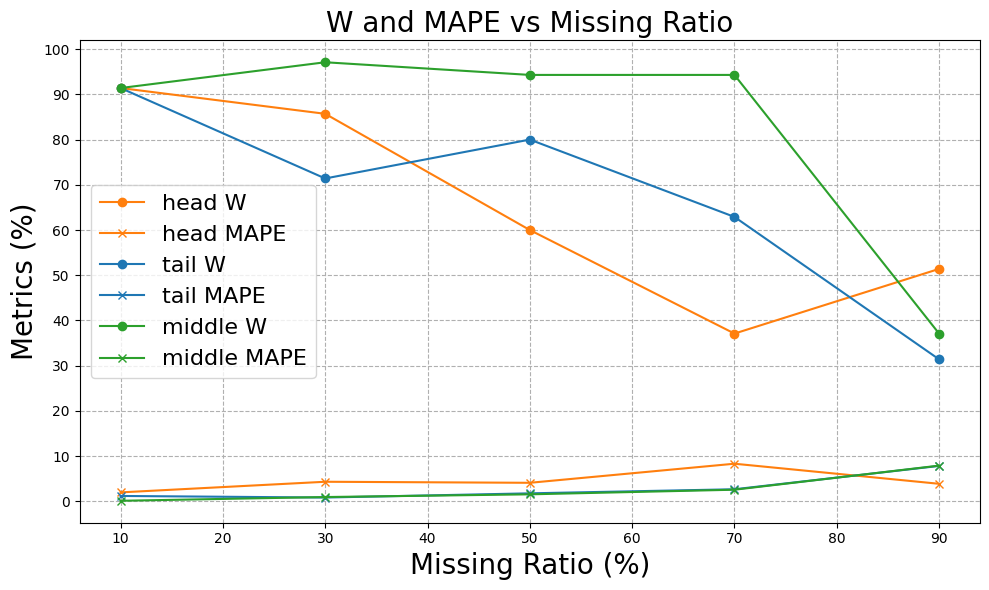

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mticker  # 追加

# DataFrame はそのまま
data = {
    "欠損割合": [10.0, 30.0, 50.0, 70.0, 90.0],
    "head_W": [91.4, 85.7, 60.0, 37.1, 51.4],
    "head_MAPE": [1.98, 4.33, 4.10, 8.32, 3.88],
    "tail_W": [91.4, 71.4, 80.0, 62.9, 31.4],
    "tail_MAPE": [1.19, 0.84, 1.77, 2.67, 7.83],
    "middle_W": [91.4, 97.1, 94.3, 94.3, 37.1],
    "middle_MAPE": [0.12, 0.95, 1.55, 2.57, 7.90],
}
df = pd.DataFrame(data)

fig, ax = plt.subplots(figsize=(10, 6))

# --- プロットはそのまま ---
ax.plot(df["欠損割合"], df["head_W"], label="head W", marker="o", linestyle="-", color="tab:orange")
ax.plot(df["欠損割合"], df["head_MAPE"], label="head MAPE", marker="x", linestyle="-", color="tab:orange")
ax.plot(df["欠損割合"], df["tail_W"], label="tail W", marker="o", linestyle="-", color="tab:blue")
ax.plot(df["欠損割合"], df["tail_MAPE"], label="tail MAPE", marker="x", linestyle="-", color="tab:blue")
ax.plot(df["欠損割合"], df["middle_W"], label="middle W", marker="o", linestyle="-", color="tab:green")
ax.plot(df["欠損割合"], df["middle_MAPE"], label="middle MAPE", marker="x", linestyle="-", color="tab:green")

# --- ここから目盛り＆グリッド設定 ---
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))


# グリッドを表示
ax.grid(which="major", linestyle="--")
# ----------------------------------------------------------------

ax.set_title("W and MAPE vs Missing Ratio", fontsize=20)
ax.set_xlabel("Missing Ratio (%)", fontsize=20)
ax.set_ylabel("Metrics (%)", fontsize=20)
ax.legend(fontsize=16)

plt.tight_layout()
plt.show()

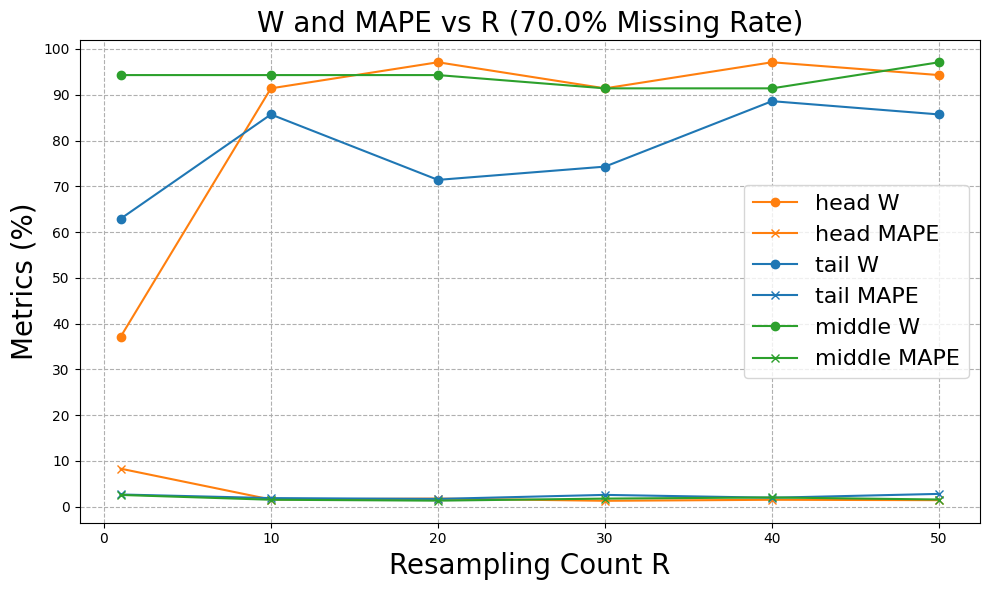

In [8]:
import matplotlib.pyplot as plt

# Resampling回数 R
R_values = [1, 10, 20, 30, 40, 50]

# 欠損割合70.0%における W および MAPE のデータ（手動で表から抽出）
data = {
    "head": {
        "W": [37.1, 91.4, 97.1, 91.4, 97.1, 94.3],
        "MAPE": [8.31, 1.57, 1.78, 1.29, 1.51, 1.43],
    },
    "tail": {
        "W": [62.9, 85.7, 71.4, 74.3, 88.6, 85.7],
        "MAPE": [2.67, 1.88, 1.70, 2.58, 1.96, 2.80],
    },
    "middle": {
        "W": [94.3, 94.3, 94.3, 91.4, 91.4, 97.1],
        "MAPE": [2.57, 1.52, 1.32, 1.77, 2.02, 1.57],
    },
}

# 色の定義（指定通り）
colors = {"head": "tab:orange", "tail": "tab:blue", "middle": "tab:green"}

# グラフ描画
fig, ax = plt.subplots(figsize=(10, 6))

for mode in data:
    ax.plot(R_values, data[mode]["W"], marker="o", label=f"{mode} W", color=colors[mode])
    ax.plot(R_values, data[mode]["MAPE"], marker="x", label=f"{mode} MAPE", color=colors[mode])

# --- ここから目盛り＆グリッド設定 ---
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))


# グリッドを表示
ax.grid(which="major", linestyle="--")
# ----------------------------------------------------------------

ax.set_title("W and MAPE vs R (70.0% Missing Rate)", fontsize=20)
ax.set_xlabel("Resampling Count R", fontsize=20)
ax.set_ylabel("Metrics (%)", fontsize=20)
ax.legend(fontsize=16)

plt.tight_layout()
plt.show()

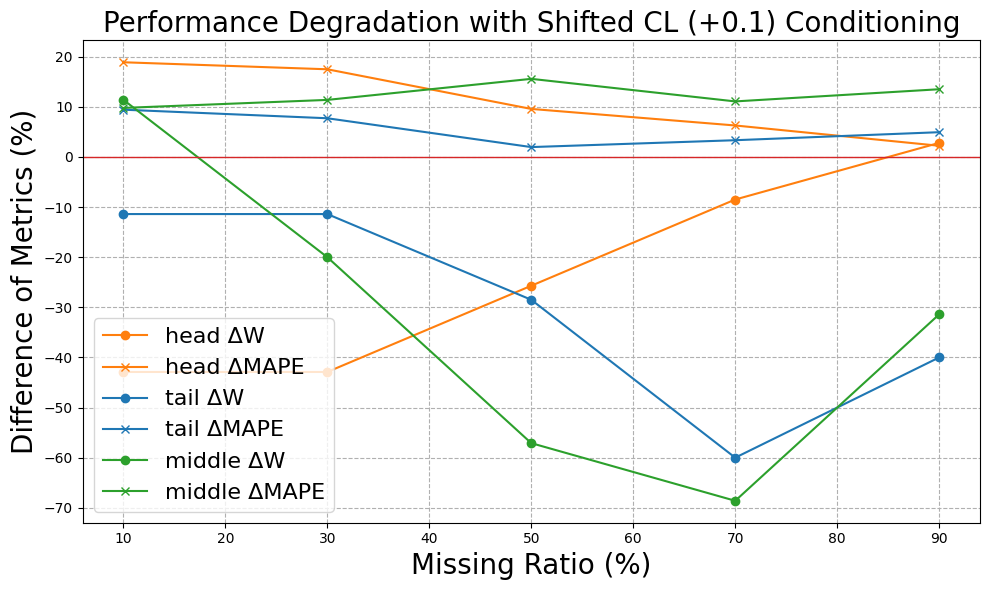

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mticker  # 追加

# 欠損割合
missing_ratios = [10.0, 30.0, 50.0, 70.0, 90.0]

# Cl条件での性能データ（WとMAPE）
cl_data = {
    "head": {
        "W": [94.3, 94.3, 88.6, 91.4, 88.6],
        "MAPE": [0.61, 2.27, 1.00, 1.57, 2.51],
    },
    "tail": {
        "W": [97.1, 85.7, 71.4, 85.7, 71.4],
        "MAPE": [0.81, 0.85, 2.49, 1.88, 2.55],
    },
    "middle": {
        "W": [88.6, 88.6, 91.4, 94.3, 77.1],
        "MAPE": [0.10, 0.80, 1.50, 1.52, 3.90],
    },
}

# Cl+0.1条件での性能データ（WとMAPE）
cl_shift_data = {
    "head": {
        "W": [51.4, 51.4, 62.9, 82.9, 91.4],
        "MAPE": [19.49, 19.75, 10.57, 7.84, 4.73],
    },
    "tail": {
        "W": [85.7, 74.3, 42.9, 25.7, 31.4],
        "MAPE": [10.23, 8.56, 4.45, 5.21, 7.48],
    },
    "middle": {
        "W": [100.0, 68.6, 34.3, 25.7, 45.7],
        "MAPE": [9.87, 12.17, 17.07, 12.59, 17.40],
    },
}

# 差分（Cl+0.1 - Cl）を計算
diff_data = {}
for mode in cl_data:
    diff_data[mode] = {
        "delta_W": [s - o for s, o in zip(cl_shift_data[mode]["W"], cl_data[mode]["W"])],
        "delta_MAPE": [s - o for s, o in zip(cl_shift_data[mode]["MAPE"], cl_data[mode]["MAPE"])],
    }

# 色設定
colors = {"head": "tab:orange", "tail": "tab:blue", "middle": "tab:green"}

# グラフ描画
fig, ax = plt.subplots(figsize=(10, 6))
for mode in diff_data:
    ax.plot(missing_ratios, diff_data[mode]["delta_W"], marker="o", label=f"{mode} ΔW", color=colors[mode])
    ax.plot(missing_ratios, diff_data[mode]["delta_MAPE"], marker="x", label=f"{mode} ΔMAPE", color=colors[mode])

ax.axhline(0, color="tab:red", linestyle="-", linewidth=1)

# --- ここから目盛り＆グリッド設定 ---
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))


# グリッドを表示
ax.grid(which="major", linestyle="--")
# ----------------------------------------------------------------

ax.set_title("Performance Degradation with Shifted CL (+0.1) Conditioning", fontsize=20)
ax.set_xlabel("Missing Ratio (%)", fontsize=20)
ax.set_ylabel("Difference of Metrics (%)", fontsize=20)
ax.legend(fontsize=16)

plt.tight_layout()
plt.show()

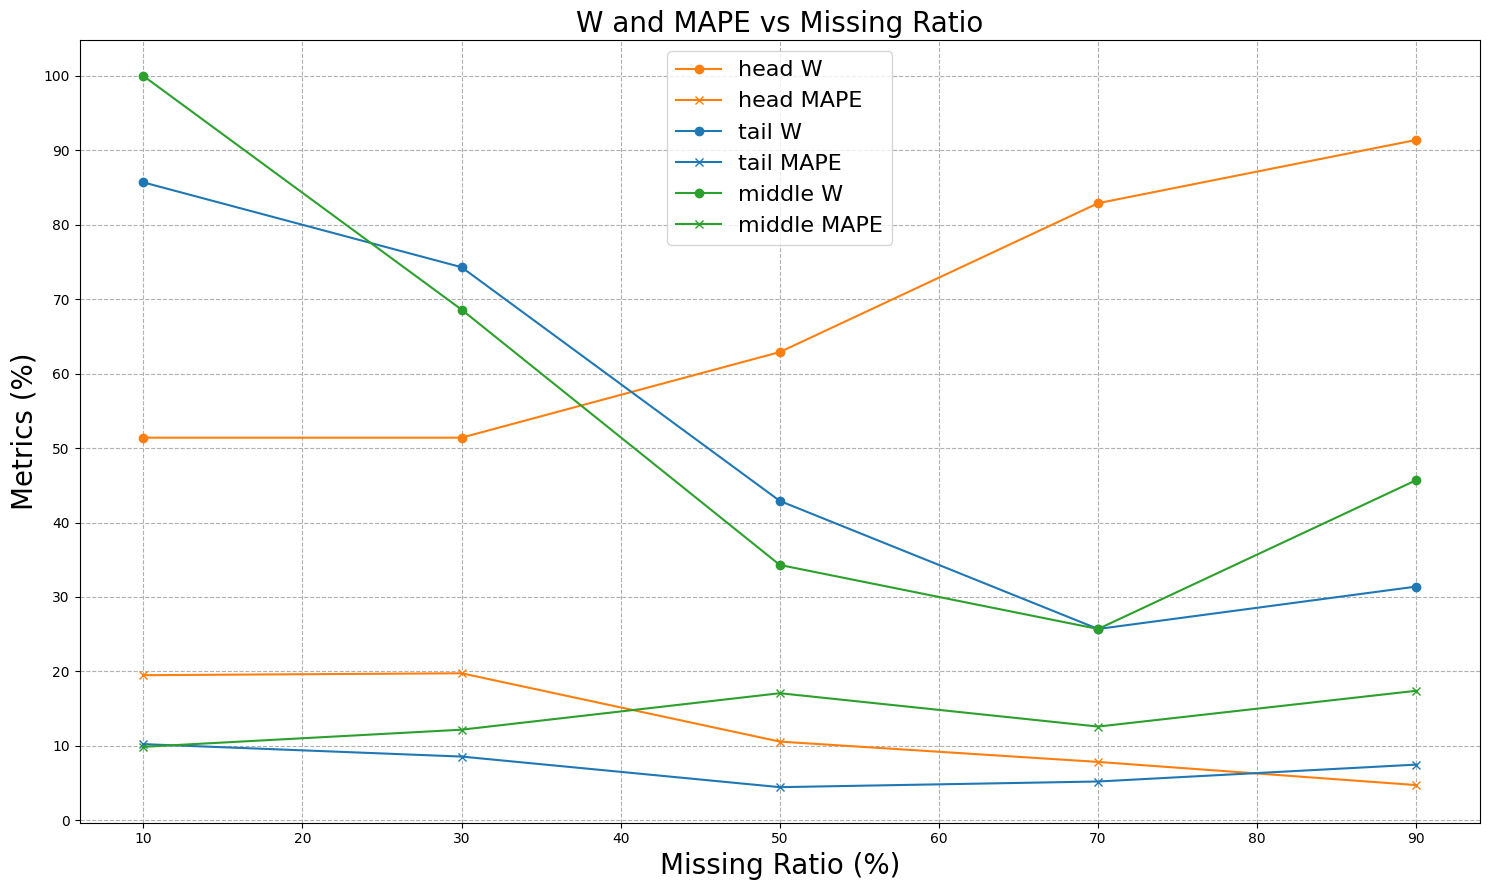

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mticker  # 追加

# DataFrame はそのまま
data = {
    "欠損割合": [10.0, 30.0, 50.0, 70.0, 90.0],
    "head_W": [51.4, 51.4, 62.9, 82.9, 91.4],
    "head_MAPE": [19.49, 19.75, 10.57, 7.84, 4.73],
    "tail_W": [85.7, 74.3, 42.9, 25.7, 31.4],
    "tail_MAPE": [10.23, 8.56, 4.45, 5.21, 7.48],
    "middle_W": [100.0, 68.6, 34.3, 25.7, 45.7],
    "middle_MAPE": [9.87, 12.17, 17.07, 12.59, 17.40],
}
df = pd.DataFrame(data)

fig, ax = plt.subplots(figsize=(15, 9))

# --- プロットはそのまま ---
ax.plot(df["欠損割合"], df["head_W"], label="head W", marker="o", linestyle="-", color="tab:orange")
ax.plot(df["欠損割合"], df["head_MAPE"], label="head MAPE", marker="x", linestyle="-", color="tab:orange")
ax.plot(df["欠損割合"], df["tail_W"], label="tail W", marker="o", linestyle="-", color="tab:blue")
ax.plot(df["欠損割合"], df["tail_MAPE"], label="tail MAPE", marker="x", linestyle="-", color="tab:blue")
ax.plot(df["欠損割合"], df["middle_W"], label="middle W", marker="o", linestyle="-", color="tab:green")
ax.plot(df["欠損割合"], df["middle_MAPE"], label="middle MAPE", marker="x", linestyle="-", color="tab:green")

# --- ここから目盛り＆グリッド設定 ---
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))


# グリッドを表示
ax.grid(which="major", linestyle="--")
# ----------------------------------------------------------------

ax.set_title("W and MAPE vs Missing Ratio", fontsize=20)
ax.set_xlabel("Missing Ratio (%)", fontsize=20)
ax.set_ylabel("Metrics (%)", fontsize=20)
ax.legend(fontsize=16)

plt.tight_layout()
plt.show()